In [18]:
# In this notebook we will be using UMAP tools to visualize our larger catalog of galaxies
import numpy as np
import pandas as pd
from astropy.io import fits
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.pyplot as plt

In [19]:
# So lets get our eboss catalog set up first!
data_folder_name = 'data'
filename_summary = 'eboss_dr17_summary_dr2_v1.fit'
filename_weights = 'eboss_dr17_weights_dr2_v1.fit'

file_path_summary = os.path.join('..', data_folder_name, filename_summary)
file_path_weights = os.path.join('..', data_folder_name, filename_weights)

with fits.open(file_path_summary) as hdu_summary:
    eBOSS_summary = pd.DataFrame({
        'PLATE': list(hdu_summary[1].data['PLATE']),
        'MJD': list(hdu_summary[1].data['MJD']),
        'FIBER': list(hdu_summary[1].data['FIBER']),
        'PMF_STRING': list(hdu_summary[1].data['PMF_STRING']),
        'Z': list(hdu_summary[1].data['Z']),
        'Z_ERR': list(hdu_summary[1].data['Z_ERR']),
        'RA': list(hdu_summary[1].data['RA']),
        'DEC': list(hdu_summary[1].data['DEC']),
        'H_ALPHA_EW': list(hdu_summary[1].data['H_ALPHA_EW']),
        'H_BETA_EW': list(hdu_summary[1].data['H_BETA_EW']),
        'OII_EW': list(hdu_summary[1].data['OII_3727_EW']),
        'D_4000': list(hdu_summary[1].data['DN4000']),
        'D_4000_ERR': list(hdu_summary[1].data['DN4000_ERR']),
        'LICK_HDA': list(hdu_summary[1].data['LICK_HDA']),
        'LICK_HDA_ERR': list(hdu_summary[1].data['LICK_HDA_ERR']),
        'BALMERBREAK': list(hdu_summary[1].data['BALMERBREAK']),
        'BALMERBREAK_ERR': list(hdu_summary[1].data['BALMERBREAK_ERR']),
        'BPT_CLASS': list(hdu_summary[1].data['BPT_CLASS']),
        'SN_MEDIAN_ALL': list(hdu_summary[1].data['SN_MEDIAN'])
    })

# check how the pmf_string data is stored
if isinstance(eBOSS_summary['PMF_STRING'].iloc[0], bytes):
    eBOSS_summary['PMF_STRING'] = eBOSS_summary['PMF_STRING'].str.decode('utf-8') # convert to text strings

# open the FITS file then extract the data/weights
with fits.open(file_path_weights) as hdu_weights:
    data_weights = hdu_weights[1].data
    dict_weights = {name: list(data_weights[name]) for name in data_weights.dtype.names}
    df_weights = pd.DataFrame(dict_weights)

# check if the pmf_string column in the new dataframe is stored still just as raw bytes
if isinstance(df_weights['PMF_STRING'].iloc[0], bytes):
    df_weights['PMF_STRING'] = df_weights['PMF_STRING'].str.decode('utf-8')

# Merge catalogs!
eBOSS_catalog = pd.merge(eBOSS_summary, df_weights, on='PMF_STRING', suffixes=('', '_weights'))

In [20]:
# now we are going to apply some filters to our larger catalog so our UMAP plot doesn't get completely clouded up

# We will be making a redshift cut to only include z = 0.4-0.6 as well as a S/N ratio cut at >= 3 
filtered_catalog = eBOSS_catalog[
    (eBOSS_catalog['Z'] >= 0.4) & 
    (eBOSS_catalog['Z'] <= 0.6) & 
    (eBOSS_catalog['SN_MEDIAN_ALL'] >= 3)
].copy()

# I'm also going to reset the index to make sure the indexing is still correct
filtered_catalog.reset_index(drop=True, inplace=True)

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


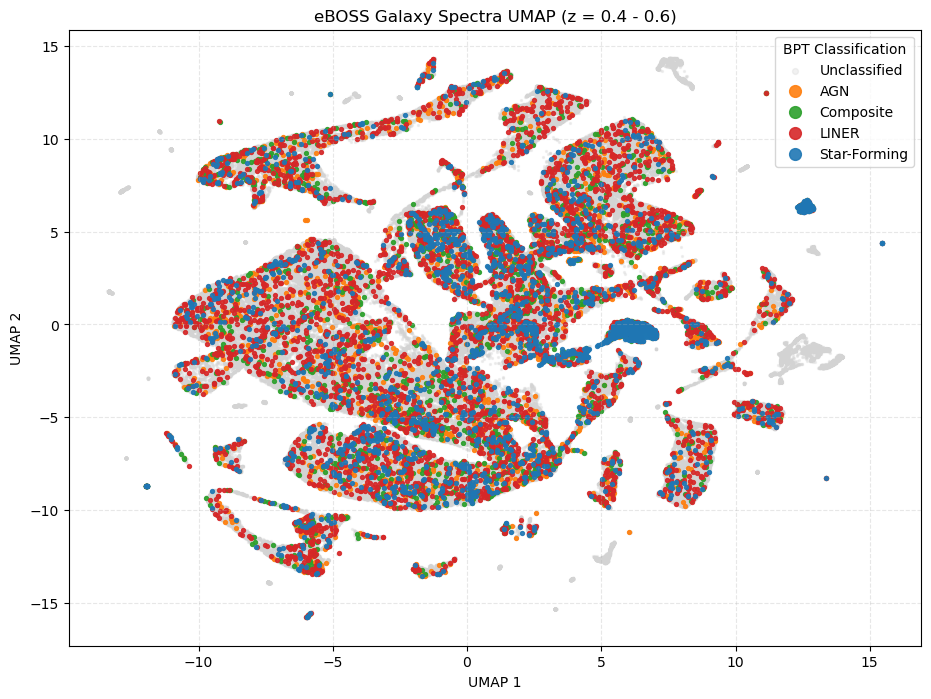

In [24]:
# Now we can actually begin apply UMAP

# Step one: we need to select the columns that will be used to "train" UMAP 
exclude_cols = [
    'PLATE', 'MJD', 'FIBER', 'PMF_STRING', 'RA', 'DEC', 'Z', 'Z_ERR', 
    'D_4000_ERR', 'LICK_HDA_ERR', 'BALMERBREAK_ERR', 'SN_MEDIAN_ALL'
] # we don't need any ID strings, coordinates, or error columns

# meaning our included columns will just be everything else
numeric_df = filtered_catalog.select_dtypes(include=['float64', 'int64', 'float32', 'int32'])
feature_cols = [col for col in numeric_df.columns if col not in exclude_cols]

# Step Two: exclude any rows will missing/invalid data
clean_data = filtered_catalog.dropna(subset=feature_cols).copy()
X = clean_data[feature_cols].values

# Step three: we will now scale the featues so there are no single lines/weights dominating all others
X_scaled = StandardScaler().fit_transform(X)

# Step four: now we can initialize and fit UMAP
# reducer comes first to narrow down our dimensions
reducer = umap.UMAP(
    n_neighbors=30,      
    min_dist=0.1,        
    metric='euclidean',  
    random_state=42
)

embedding = reducer.fit_transform(X_scaled)

# Step five: create the scatter plot with layered plotting and clear labels
plt.figure(figsize=(11, 8))

# I am going to define labels for the BPT categories so we can create a legend
bpt_label_map = {
    'S': 'Star-Forming',
    'SF': 'Star-Forming',
    'C': 'Composite',
    'Sy': 'Seyfert (AGN)',
    'A': 'AGN',
    'L': 'LINER',
    'U': 'Unclassified'
}

clean_data['BPT_LABEL'] = clean_data['BPT_CLASS'].map(lambda x: bpt_label_map.get(x, str(x)))

# after some trial and error... I selected colors to make the unclassified galaxies less overwhelming in the final plot
color_dict = {
    'Unclassified': '#d3d3d3',  # grey
    'Star-Forming': '#1f77b4',  # blue
    'Composite': '#2ca02c',     # green
    'AGN': '#ff7f0e',           # orange
    'Seyfert (AGN)': '#ff7f0e', # orange
    'LINER': '#d62728'          # red
}

# UPDATE: i need to plot the unclassified galaxies FIRST because otherwise the completely dominate the other types and you can't see them
unclass_mask = (clean_data['BPT_LABEL'] == 'Unclassified').values
plt.scatter(
    embedding[unclass_mask, 0], 
    embedding[unclass_mask, 1], 
    label='Unclassified',
    color=color_dict.get('Unclassified', '#d3d3d3'),
    s=2, 
    alpha=0.3  
)

# now we can plot the classified galaxies so they appear on top
classified_labels = [lbl for lbl in sorted(clean_data['BPT_LABEL'].unique()) if lbl != 'Unclassified']

for label in classified_labels:
    mask = (clean_data['BPT_LABEL'] == label).values
    plt.scatter(
        embedding[mask, 0], 
        embedding[mask, 1], 
        label=label,
        color=color_dict.get(label, None),
        s=8,        
        alpha=0.9   
    )

plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('eBOSS Galaxy Spectra UMAP (z = 0.4 - 0.6)')
plt.grid(True, linestyle='--', alpha=0.3)

# add a legend
plt.legend(title='BPT Classification', markerscale=3, loc='upper right')
plt.show()

In [22]:
# okay, now in order to create a UMAP plot of just our young psb selection, we need to redefine them
# This is a direct copy of the masking we did in notebook #2 
standard_outliar_mask = (
    (eBOSS_catalog['LICK_HDA'] > -5) & (eBOSS_catalog['LICK_HDA'] < 13) & 
    (eBOSS_catalog['D_4000'] > 0) & (eBOSS_catalog['D_4000'] < 2.5) & 
    (eBOSS_catalog['BALMERBREAK'] > 0) & (eBOSS_catalog['BALMERBREAK'] < 3.5) 
)

line_outliar_mask = (
    ((eBOSS_catalog['Z'] <= 0.49) & 
     (eBOSS_catalog['H_ALPHA_EW'] > 0) & 
     (eBOSS_catalog['H_BETA_EW'] > 0)
    )
    |
    (
        (eBOSS_catalog['Z'] > 0.49) & 
        (
          (eBOSS_catalog['H_BETA_EW'] > 0) | 
          (eBOSS_catalog['OII_EW'] > 0)
        )
     )
)

filtered_base = eBOSS_catalog[standard_outliar_mask & line_outliar_mask].copy()

HALPHA_YOUNG_PSB_CUT = 7.0

young_psb_mask = (
    (filtered_base['BALMERBREAK'] > 0.9) & (filtered_base['BALMERBREAK'] < 1.9) &
    (filtered_base['LICK_HDA'] > (filtered_base['BALMERBREAK'] * 5.2 - 4.7)) &
    (filtered_base['BALMERBREAK'] > (filtered_base['D_4000'] * 7.0 - 6.5)) &
    (filtered_base['H_BETA_EW'] < 5.0) &
    (
        ((filtered_base['Z'] <= 0.49) & 
         (filtered_base['H_ALPHA_EW'] > -900) & 
         (filtered_base['H_ALPHA_EW'] < HALPHA_YOUNG_PSB_CUT))
        |
        (filtered_base['Z'] > 0.49)
    )
)

young_psb_catalog = filtered_base[young_psb_mask].copy()
young_psb_catalog.reset_index(drop=True, inplace=True)
print(f"Total Young PSBs : {len(young_psb_catalog)}") # just making sure we have the same number of young psbs identified as we did in notebook #2


Total Young PSBs : 2537


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


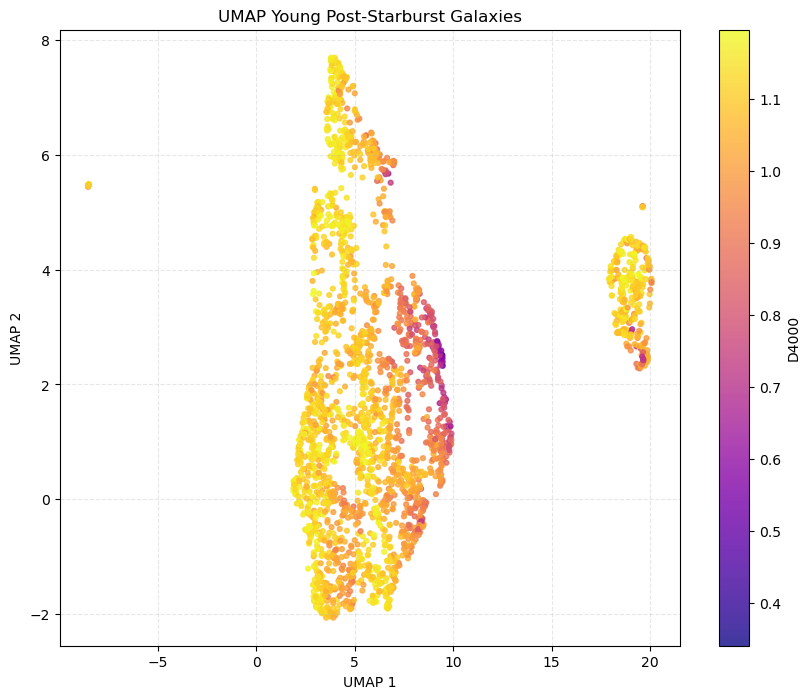

In [25]:
# okay now we can begin utilizing the UMAP features
exclude_cols = [
    'PLATE', 'MJD', 'FIBER', 'PMF_STRING', 'RA', 'DEC', 'Z', 'Z_ERR', 
    'D_4000_ERR', 'LICK_HDA_ERR', 'BALMERBREAK_ERR', 'SN_MEDIAN_ALL', 'PSB_CLASS'
]

numeric_df = young_psb_catalog.select_dtypes(include=['float64', 'int64', 'float32', 'int32'])
feature_cols = [col for col in numeric_df.columns if col not in exclude_cols]

clean_young_psb = young_psb_catalog.dropna(subset=feature_cols).copy()
X = clean_young_psb[feature_cols].values

X_scaled = StandardScaler().fit_transform(X)

reducer_psb = umap.UMAP(
    n_neighbors=15,     
    min_dist=0.1,        
    metric='euclidean',  
    random_state=42
)

embedding_psb = reducer_psb.fit_transform(X_scaled)

# I am plotting the young PSB UMAP colored by D_4000 strength because we know each of our galaxies are guarenteed to have a D4000 value
# this can be easily changed though
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embedding_psb[:, 0], 
    embedding_psb[:, 1], 
    c=clean_young_psb['D_4000'], 
    cmap='plasma', 
    s=12, 
    alpha=0.8
)

plt.colorbar(scatter, label=r'D4000')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP Young Post-Starburst Galaxies')
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()